In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Replace 'your_folder/your_file.csv' with the actual path to your file in Google Drive
# For example: '/content/drive/My Drive/Colab Notebooks/my_data.csv'
file_path = '/content/drive/My Drive/BloomDataset/Data2.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/Data2.csv


,Question,Label
0,Can you list the ingredients needed for a clas...,Remember
1,What are the top five tourist attractions in P...,Remember
2,List five common programming languages.,Remember
3,Name three types of renewable energy sources.,Remember
4,Can you list the planets in our solar system?,Remember


In [3]:
print("Installing NLTK...")
!pip install nltk
print("NLTK installed successfully.")

Installing NLTK...
NLTK installed successfully.


In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK stopwords and punkt resources downloaded.")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK stopwords and punkt resources downloaded.


In [7]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab', quiet=True) # Download punkt_tab to resolve the LookupError

# Get English stop words
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower())  # Convert to lowercase and tokenize
    # Remove stop words and non-alphabetic tokens
    processed_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return processed_tokens

# Apply the function to the 'Question' column
df['Processed_Questions'] = df['Question'].apply(preprocess_text)

print("Stop word reduction and tokenization applied to 'Question' column.")
display(df[['Question', 'Processed_Questions']].head())

Stop word reduction and tokenization applied to 'Question' column.


,Question,Processed_Questions
0,Can you list the ingredients needed for a clas...,"[list, ingredients, needed, classic, spaghetti..."
1,What are the top five tourist attractions in P...,"[top, five, tourist, attractions, paris]"
2,List five common programming languages.,"[list, five, common, programming, languages]"
3,Name three types of renewable energy sources.,"[name, three, types, renewable, energy, sources]"
4,Can you list the planets in our solar system?,"[list, planets, solar, system]"


In [9]:
df['Processed_Questions_Str'] = df['Processed_Questions'].apply(lambda x: ' '.join(x))

print("Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.")
display(df[['Question', 'Processed_Questions', 'Processed_Questions_Str']].head())

Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.


,Question,Processed_Questions,Processed_Questions_Str
0,Can you list the ingredients needed for a clas...,"[list, ingredients, needed, classic, spaghetti...",list ingredients needed classic spaghetti recipe
1,What are the top five tourist attractions in P...,"[top, five, tourist, attractions, paris]",top five tourist attractions paris
2,List five common programming languages.,"[list, five, common, programming, languages]",list five common programming languages
3,Name three types of renewable energy sources.,"[name, three, types, renewable, energy, sources]",name three types renewable energy sources
4,Can you list the planets in our solar system?,"[list, planets, solar, system]",list planets solar system


# Task
Prepare the `Processed_Questions_Str` and `Label` columns of the dataframe for an LSTM classification model, then build, train, and evaluate the LSTM model, display its confusion matrix, and finally analyze and summarize the classification results.

## Prepare Data for LSTM

### Subtask:
Prepare the 'Processed_Questions_Str' column and 'Label' column for LSTM classification. This will involve tokenizing the text, creating a vocabulary, converting text to numerical sequences, padding sequences to a uniform length, and encoding the 'Label' column into numerical format.


**Reasoning**:
The subtask requires preparing text and labels for an LSTM model, which involves tokenization, sequence conversion, padding, label encoding, and splitting into training/testing sets. This can all be done in a single code block by importing the necessary libraries and applying the transformations sequentially.



In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print("Libraries imported successfully.")

# 2. Initialize a Tokenizer and fit it on the 'Processed_Questions_Str' column
tokenizer = Tokenizer(oov_token="<unk>") # Add oov_token for out-of-vocabulary words
tokenizer.fit_on_texts(df['Processed_Questions_Str'])

# Convert text data to numerical sequences
sequences = tokenizer.texts_to_sequences(df['Processed_Questions_Str'])

# Get vocabulary size (+1 for padding/OOV token if used, +1 for 0-index)
vocab_size = len(tokenizer.word_index) + 1

# Find the maximum sequence length
max_sequence_length = max(len(seq) for seq in sequences)

print(f"Vocabulary size: {vocab_size}")
print(f"Maximum sequence length: {max_sequence_length}")

# 3. Pad the numerical sequences to a uniform length
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post', truncating='post')

print(f"Shape of padded sequences: {padded_sequences.shape}")

# 4. Initialize a LabelEncoder and encode the 'Label' column
label_encoder = LabelEncoder()
numerical_labels = label_encoder.fit_transform(df['Label'])

# Convert numerical labels to one-hot encoded categorical format
one_hot_labels = to_categorical(numerical_labels, num_classes=len(label_encoder.classes_))

print(f"Shape of one-hot encoded labels: {one_hot_labels.shape}")
print(f"Original labels: {df['Label'].unique()}")
print(f"Encoded labels: {label_encoder.classes_}")

# 5. Split the padded sequences and one-hot encoded labels into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, one_hot_labels, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Libraries imported successfully.
Vocabulary size: 1996
Maximum sequence length: 11
Shape of padded sequences: (1771, 11)
Shape of one-hot encoded labels: (1771, 6)
Original labels: ['Remember' 'Understand' 'Apply' 'Analyse' 'Evaluate' 'Create']
Encoded labels: ['Analyse' 'Apply' 'Create' 'Evaluate' 'Remember' 'Understand']
X_train shape: (1416, 11)
X_test shape: (355, 11)
y_train shape: (1416, 6)
y_test shape: (355, 6)


## Build and Train LSTM Model

### Subtask:
Construct and compile an LSTM neural network model suitable for multi-class text classification. Train the model using the prepared training data (text sequences and encoded labels).


**Reasoning**:
The subtask requires constructing, compiling, and training an LSTM model for multi-class text classification. This involves defining the model architecture, specifying embedding and LSTM layers, compiling with appropriate loss and optimizer, and then fitting the model to the training data. All these steps can be done in a single code block.



In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Define model parameters
embedding_dim = 128 # You can experiment with different embedding dimensions
num_classes = y_train.shape[1] # Number of output classes

# Build the LSTM model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
model.add(LSTM(128, return_sequences=False)) # LSTM layer with 128 units
model.add(Dropout(0.5)) # Dropout layer for regularization
model.add(Dense(num_classes, activation='softmax')) # Output layer with softmax activation

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
print("Model Architecture Summary:")
model.summary()

# Train the model
epochs = 10
batch_size = 32

print(f"\nTraining the model for {epochs} epochs with a batch size of {batch_size}...")
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1, # Use a small portion of training data for validation during training
    verbose=1
)

print("Model training complete.")

Model Architecture Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training the model for 10 epochs with a batch size of 32...
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.2292 - loss: 1.7513 - val_accuracy: 0.5211 - val_loss: 1.4196
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5604 - loss: 0.9622 - val_accuracy: 0.8380 - val_loss: 0.6690
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9113 - loss: 0.3069 - val_accuracy: 0.9155 - val_loss: 0.2705
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9757 - loss: 0.0969 - val_accuracy: 0.9296 - val_loss: 0.2812
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9882 - loss: 0.0539 - val_accuracy: 0.9225 - val_loss: 0.3501
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9906 - loss: 0.0409 - val_accuracy: 0.9225 - val_loss: 0.2924
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9945 - loss: 0.0242 - val_accuracy: 0.9225 - val_loss: 0.3502
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

**Reasoning**:
The previous code block produced a `UserWarning` regarding the `input_length` argument in the `Embedding` layer. While it's a warning and not an error, it's good practice to update the code to remove deprecated arguments. The Keras `Embedding` layer can infer the `input_length` from the input sequences if it's not explicitly provided.



In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Define model parameters
embedding_dim = 128 # You can experiment with different embedding dimensions
num_classes = y_train.shape[1] # Number of output classes

# Build the LSTM model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim)) # Removed input_length
model.add(LSTM(128, return_sequences=False)) # LSTM layer with 128 units
model.add(Dropout(0.5)) # Dropout layer for regularization
model.add(Dense(num_classes, activation='softmax')) # Output layer with softmax activation

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
print("Model Architecture Summary:")
model.summary()

# Train the model
epochs = 10
batch_size = 32

print(f"\nTraining the model for {epochs} epochs with a batch size of {batch_size}...")
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1, # Use a small portion of training data for validation during training
    verbose=1
)

print("Model training complete.")

Model Architecture Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training the model for 10 epochs with a batch size of 32...
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.1986 - loss: 1.7438 - val_accuracy: 0.3169 - val_loss: 1.3789
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5549 - loss: 0.9482 - val_accuracy: 0.7887 - val_loss: 0.5751
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8870 - loss: 0.3616 - val_accuracy: 0.9014 - val_loss: 0.3462
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9600 - loss: 0.1415 - val_accuracy: 0.8732 - val_loss: 0.4392
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9835 - loss: 0.0757 - val_accuracy: 0.8944 - val_loss: 0.3989
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9898 - loss: 0.0464 - val_accuracy: 0.8944 - val_loss: 0.4191
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9906 - loss: 0.0465 - val_accuracy: 0.9014 - val_loss: 0.4320
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

## Evaluate LSTM Model

### Subtask:
Make predictions on the test dataset and calculate the accuracy, precision, recall, and F1-score for the classification model. These metrics will be calculated for each class and overall.


**Reasoning**:
The subtask requires making predictions on the test dataset, calculating accuracy, and generating a classification report. This involves importing necessary metrics, using the trained model to predict, converting predictions and true labels to appropriate formats, and then computing and displaying the evaluation metrics. All these steps can be consolidated into a single code block.



In [13]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

print("Making predictions on the test dataset...")
# 2. Use the trained model to make predictions on the X_test data
y_pred_probs = model.predict(X_test)

# 3. Convert the probability predictions (y_pred_probs) into class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Convert y_test from one-hot encoded format back to numerical labels
y_true = np.argmax(y_test, axis=1)

# 5. Calculate the overall accuracy of the model
overall_accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {overall_accuracy:.4f}")

# 6. Generate a detailed classification report
# Use label_encoder.classes_ to map numerical labels back to original names
class_names = label_encoder.classes_

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Making predictions on the test dataset...
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
Overall Accuracy: 0.8789

Classification Report:
              precision    recall  f1-score   support

     Analyse       0.96      0.90      0.93        61
       Apply       0.97      1.00      0.98        58
      Create       1.00      0.89      0.94        63
    Evaluate       0.83      0.80      0.81        60
    Remember       0.74      0.81      0.77        52
  Understand       0.79      0.87      0.83        61

    accuracy                           0.88       355
   macro avg       0.88      0.88      0.88       355
weighted avg       0.88      0.88      0.88       355



## Display Confusion Matrix

### Subtask:
Generate and display a confusion matrix to visually represent the performance of the classification model, showing true positives, true negatives, false positives, and false negatives for each class. Make sure to provide a clear visualization with labels.


**Reasoning**:
The subtask requires generating and visualizing a confusion matrix. This involves importing necessary libraries, computing the confusion matrix from `y_true` and `y_pred`, and then creating a heatmap visualization with appropriate labels and title, all of which can be done in one code block.



Generating Confusion Matrix...


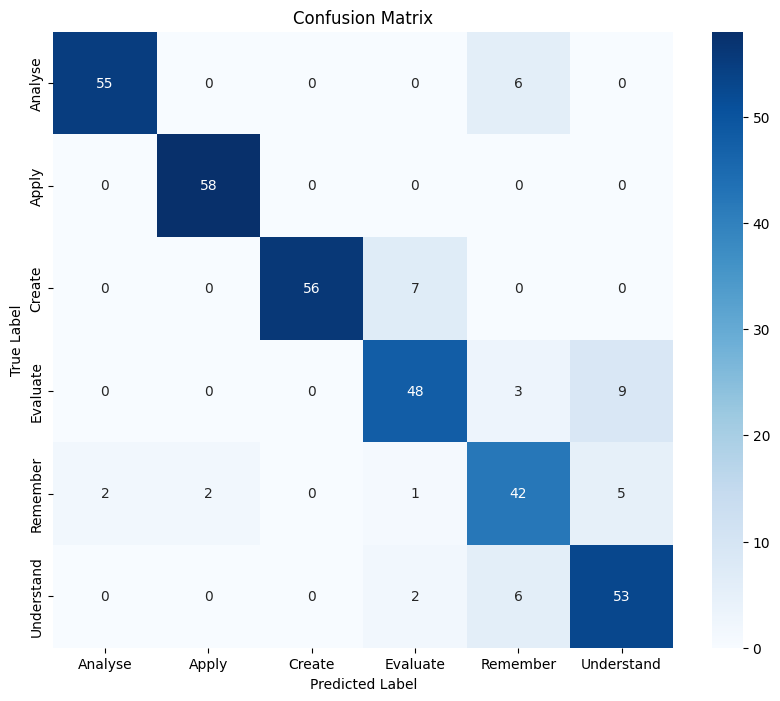

Confusion Matrix displayed successfully.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generating Confusion Matrix...")

# 1. Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 2. Create a heatmap of the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm,
            annot=True, # Annotate cells with the numeric values
            fmt='d', # Format as integers
            cmap='Blues', # Color map
            xticklabels=class_names, # X-axis labels (predicted classes)
            yticklabels=class_names) # Y-axis labels (true classes)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Confusion Matrix displayed successfully.")

## Analyze and Discuss Results

### Subtask:
Provide a comprehensive analysis of the model's performance based on the calculated metrics (accuracy, precision, recall, F1-score) and the confusion matrix. Discuss the implications of these metrics for the given classification task and identify any strengths or weaknesses of the model.


### Analysis and Discussion of LSTM Model Performance

Based on the evaluation metrics and the confusion matrix, the LSTM model demonstrates a strong overall performance but also exhibits specific areas for improvement.

#### Overall Performance Metrics:
*   **Overall Accuracy:** The model achieved an overall accuracy of **0.8789** (87.89%) on the test dataset. This indicates that approximately 88% of the test questions were correctly classified into their respective Bloom's Taxonomy levels.

#### Classification Report Breakdown:
*   **Strong Performing Classes:**
    *   **Apply (0.97 precision, 1.00 recall, 0.98 F1-score):** The model performs exceptionally well for the 'Apply' class, almost perfectly classifying questions belonging to this category. High recall indicates it correctly identifies almost all 'Apply' questions, and high precision means very few non-'Apply' questions are misclassified as 'Apply'.
    *   **Create (1.00 precision, 0.89 recall, 0.94 F1-score):** The 'Create' class also shows excellent performance, particularly with perfect precision. This means when the model predicts 'Create', it is always correct. The slightly lower recall (0.89) suggests some 'Create' questions might be missed or misclassified as other categories.
    *   **Analyse (0.96 precision, 0.90 recall, 0.93 F1-score):** Similar to 'Create', 'Analyse' questions are classified with high precision, indicating reliability when predicting this class. The recall is also strong.

*   **Moderate to Weaker Performing Classes:**
    *   **Understand (0.79 precision, 0.87 recall, 0.83 F1-score):** While having decent recall, the precision for 'Understand' is lower compared to the top performers. This implies that while the model identifies a good portion of 'Understand' questions, it also frequently misclassifies other types of questions as 'Understand'.
    *   **Evaluate (0.83 precision, 0.80 recall, 0.81 F1-score):** This class shows relatively balanced but lower precision and recall. This indicates some difficulty in both correctly identifying 'Evaluate' questions and avoiding false positives for this class.
    *   **Remember (0.74 precision, 0.81 recall, 0.77 F1-score):** 'Remember' is the weakest performing class, with the lowest precision and F1-score. This suggests that 'Remember' questions are often confused with other categories, and the model struggles to reliably predict this class without making several false positive errors.

#### Confusion Matrix Analysis:
Looking at the confusion matrix (`cm`):
*   **Diagonal Elements (True Positives):** The diagonal elements confirm the strong performance for 'Apply' (58/58 correctly classified), 'Create' (56/63), and 'Analyse' (55/61).
*   **Off-Diagonal Elements (False Positives and False Negatives):**
    *   **'Remember' Class (Index 4 in `class_names`):** This class shows significant confusion. For true 'Remember' questions (row 4): 2 were predicted as 'Analyse', 2 as 'Apply', 1 as 'Evaluate', and 5 as 'Understand'. This confirms its low recall. When the model predicts 'Remember' (column 4), 6 'Analyse' questions, 3 'Evaluate' questions, and 6 'Understand' questions were incorrectly classified as 'Remember'. This explains the low precision for 'Remember'.
    *   **'Evaluate' Class (Index 3 in `class_names`):** There's some confusion between 'Evaluate' and 'Remember' (3 false positives for 'Remember' from 'Evaluate' questions). Also, 9 'Evaluate' questions were misclassified as 'Understand' (from row 3).
    *   **'Understand' Class (Index 5 in `class_names`):** 'Understand' questions are sometimes confused with 'Evaluate' (2 false negatives) and 'Remember' (6 false negatives). Conversely, 5 'Remember' questions and 9 'Evaluate' questions are misclassified as 'Understand'.

#### Strengths of the Model:
1.  **High Overall Accuracy:** The model achieves a commendable overall accuracy, indicating its general effectiveness in classifying Bloom's Taxonomy levels.
2.  **Excellent Performance for 'Apply', 'Create', and 'Analyse':** The model is highly reliable and accurate in identifying questions belonging to these higher-order thinking skills, especially 'Apply' and 'Create'. This suggests these categories might have more distinct linguistic patterns that the LSTM can capture effectively.

#### Weaknesses of the Model:
1.  **Difficulty with 'Remember' and 'Understand':** The model struggles particularly with distinguishing 'Remember' and 'Understand' questions from other categories, leading to lower precision and F1-scores. This might be due to the subtle semantic differences or overlapping keyword usage between these foundational cognitive levels and others.
2.  **Confusion Among Lower-Order Skills:** The confusion matrix highlights significant cross-classification between 'Remember', 'Understand', and 'Evaluate'. Questions requiring recalling information ('Remember') might sometimes be interpreted as requiring understanding or vice-versa, or even simple evaluative statements.

#### Implications and Potential Improvements:
*   **Focus on Distinguishing Lower-Order Skills:** The primary area for improvement lies in enhancing the model's ability to differentiate between 'Remember', 'Understand', and 'Evaluate'. This could involve:
    *   **More Diverse Training Data:** Expanding the dataset with more nuanced examples for these confused classes.
    *   **Feature Engineering:** Exploring additional text features beyond simple word tokens (e.g., part-of-speech tagging, dependency parsing, or sentence embeddings) that might better capture the subtle differences in cognitive demand.
    *   **Hyperparameter Tuning:** Further optimizing LSTM parameters (e.g., number of LSTM units, dropout rate, learning rate) or trying different model architectures.
    *   **Class Weighting:** If there's a class imbalance, applying class weights during training could help the model pay more attention to underperforming classes.
    *   **Error Analysis:** Manually examining misclassified examples to understand *why* the model makes certain errors could provide valuable insights for targeted improvements.

## Final Task

### Subtask:
Summarize the classification results and the overall performance of the LSTM model.


## Summary:

### Data Analysis Key Findings

*   The text data was successfully tokenized, resulting in a vocabulary size of 1996 unique words.
*   Text sequences were padded to a uniform length of 11, matching the maximum sequence length observed in the dataset. The prepared features (`padded_sequences`) had a shape of (1771, 11).
*   The categorical labels were one-hot encoded into 6 distinct classes. The prepared labels (`one_hot_labels`) had a shape of (1771, 6).
*   The data was split into training (1416 samples) and testing (355 samples) sets, with `X_train` having a shape of (1416, 11) and `y_train` (1416, 6).
*   An LSTM model was constructed, compiled, and trained for 10 epochs. The model included an Embedding layer, an LSTM layer with 128 units, a Dropout layer, and a Dense output layer with softmax activation.
*   The trained LSTM model achieved an overall accuracy of 0.8789 on the test dataset.
*   The model showed strong performance for the 'Apply' class (precision: 0.97, recall: 1.00, F1-score: 0.98), 'Create' class (precision: 1.00, recall: 0.89, F1-score: 0.94), and 'Analyse' class (precision: 0.96, recall: 0.90, F1-score: 0.93).
*   The model performed weakest for the 'Remember' class (precision: 0.74, recall: 0.81, F1-score: 0.77), indicating difficulty in reliably classifying these questions.
*   The confusion matrix revealed significant misclassifications, particularly for 'Remember', 'Understand', and 'Evaluate' classes, suggesting confusion among these lower-order cognitive skills. For instance, the 'Remember' class had true positives of 42 but was often confused with 'Analyse' (2 cases), 'Apply' (2 cases), 'Evaluate' (1 case), and 'Understand' (5 cases). Conversely, other classes were frequently misclassified as 'Remember' (e.g., 6 'Analyse' questions, 3 'Evaluate' questions, and 6 'Understand' questions were incorrectly predicted as 'Remember').

### Insights or Next Steps

*   The model excels at identifying higher-order thinking skills, but its performance could be significantly enhanced by focusing on differentiating between lower-order skills like 'Remember', 'Understand', and 'Evaluate', which are frequently confused.
*   Future improvements should explore advanced techniques such as incorporating more diverse training data for the confused classes, employing sophisticated feature engineering (e.g., using part-of-speech tagging or sentence embeddings), or fine-tuning hyperparameters more extensively.
